# Notebook 3/3 — Walk-forward training (without leaking the future)

Prerequisite: Notebooks 1 & 2 executed (`Dossier` graph + `SIMILARITE` + `COMPONENT_PARENT` / `DFS_NEXT` / `LAST_DFS_NODE_IN_COMP`).

## The two goals

**Goal 1 — Community snapshot.** At a given date, retrieve a dossier's community **without the future nodes**. This is the point-in-time query that traverses `DFS_NEXT`.

**Goal 2 — Community features.** Turn each community into a **time-weighted** feature vector: volume per window (`IND_COM_NB_DDE_*`), **acceleration** (bursts), **strong-identifier reuse**, and **confirmation-aware** fraud/default signals (labels used only once known — see the confirmation-delay note below). All strictly leak-free.

## The walk-forward training loop

To avoid leaking the future, we train as in production, moving forward in time:

- **Step 1** — position ourselves at a date `J`.
- **Step 2** — build the WCC features (7-day / 7-month / 1-year windows) **using only the past** (`DATE_COMMANDE <= J`).
- **Step 3** — use those features to predict the **credit applications of day `J`**.
- **Step 4** — score the day, then advance `J` by one step and repeat until *today*.

We then observe whether the model **learns** over time (AUC / average precision curve).

> **Implementation tip.** A dossier's point-in-time feature only depends on its community *at its own date* (the past members). So they can be computed **in a single pass** (vectorized Step 2), then the loop can be replayed day by day in pure Python — much faster than recomputing the graph every day, while remaining strictly leak-free.


In [8]:
# Cell 1: Imports & connection

!pip install neo4j pandas numpy scikit-learn matplotlib -q

import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from neo4j import GraphDatabase

NEO4J_URI = "bolt://localhost:7687"
NEO4J_USER = "neo4j"
NEO4J_PASSWORD = "password"
NEO4J_DATABASE = "fraudwcctemporal"

driver = GraphDatabase.driver(NEO4J_URI, auth=(NEO4J_USER, NEO4J_PASSWORD))
driver.verify_connectivity()
print("✅ Connected to Neo4j")


✅ Connected to Neo4j


## Goal 1 — Community snapshot (point-in-time)

Two helpers:
- `community_as_of_event(nodos)`: the community as it existed **at the dossier's date** (its own date). This is the leak-free query for training.
- `community_as_of_date(nodos, date)`: the community at an **arbitrary date** (useful for scoring/monitoring at a common cutoff date).


In [9]:
# Cell 3: Goal 1 — point-in-time snapshot helpers

Q_AS_OF_EVENT = """
MATCH (d:Dossier {NODOS: $nodos})(()-[:DFS_NEXT]->(m))*(last)<-[:LAST_DFS_NODE_IN_COMP]-(d)
UNWIND [d] + m AS ev
RETURN ev.NODOS AS nodos, toString(ev.DATE_COMMANDE) AS date,
       ev.TOP_FRAUDE AS fraude, ev.pattern AS pattern
ORDER BY date
"""

Q_AS_OF_DATE = """
MATCH fast_fw = (e:Dossier {NODOS: $nodos} WHERE e.DATE_COMMANDE <= datetime($as_of))
  (()-[:COMPONENT_PARENT]->(future WHERE future.DATE_COMMANDE <= datetime($as_of)))*
  (head:Dossier WHERE NOT EXISTS {
     (head)-[:COMPONENT_PARENT]->(x WHERE x.DATE_COMMANDE <= datetime($as_of)) }),
  comp = (head)-[:DFS_NEXT]->*(last),
  (last)<-[:LAST_DFS_NODE_IN_COMP]-(head)
UNWIND nodes(comp) AS ev
RETURN ev.NODOS AS nodos, toString(ev.DATE_COMMANDE) AS date,
       ev.TOP_FRAUDE AS fraude, ev.pattern AS pattern
ORDER BY date
"""


def community_as_of_event(nodos):
    with driver.session(database=NEO4J_DATABASE) as s:
        return pd.DataFrame(s.run(Q_AS_OF_EVENT, nodos=nodos).data())


def community_as_of_date(nodos, as_of):
    """as_of: datetime ISO string, e.g. '2025-06-01T00:00:00'"""
    with driver.session(database=NEO4J_DATABASE) as s:
        return pd.DataFrame(s.run(Q_AS_OF_DATE, nodos=nodos, as_of=as_of).data())


# Demo: take the head of a community of size >= 5
# (size = length of the DFS_NEXT chain, not the out-degree which is always <= 1)
with driver.session(database=NEO4J_DATABASE) as s:
    seed = s.run("""
        MATCH (head:Dossier)
        WHERE NOT EXISTS {(head)-[:COMPONENT_PARENT]->()}
          AND EXISTS {(head)-[:DFS_NEXT]->()}
        CALL (head) { MATCH (head)-[:DFS_NEXT]->*(x) RETURN count(x) AS taille }
        WITH head, taille WHERE taille >= 5
        RETURN head.NODOS AS nodos ORDER BY taille DESC LIMIT 1
    """).single()

if seed:
    demo_nodos = seed["nodos"]
    print(f"Community (as of the event date) of {demo_nodos}:")
    display(community_as_of_event(demo_nodos))
else:
    demo_nodos = None
    print("No community of size >= 5 (increase N_DOSSIERS in Notebook 1).")


Community (as of the event date) of DOS_00875908:


,nodos,date,fraude,pattern
0,DOS_00876105,2024-07-31T06:57:36.78584Z,True,fraude_grande
1,DOS_00875843,2024-08-01T06:17:53.78584Z,False,fraude_grande
2,DOS_00875962,2024-08-02T20:37:27.78584Z,False,fraude_grande
3,DOS_00875894,2024-08-03T02:46:02.78584Z,True,fraude_grande
4,DOS_00876171,2024-08-03T07:01:02.78584Z,True,fraude_grande
...,...,...,...,...
644,DOS_00876161,2026-07-24T15:11:37.78584Z,True,fraude_grande
645,DOS_00876403,2026-07-27T20:54:08.78584Z,False,fraude_grande
646,DOS_00876062,2026-07-28T16:43:15.78584Z,True,fraude_grande
647,DOS_00876372,2026-07-29T23:18:57.78584Z,True,fraude_grande


## Goal 2 — Community features (Step 2), point-in-time

For each dossier `d` at date `T`, we take its **point-in-time** community (past members only, `d` excluded so as not to leak its own label) and engineer features on it. Everything is computed **strictly before `T`** → no future leakage.

### The signal we want to capture

1. **Acceleration in time** — a fraud ring often *bursts*: many applications in a few days. We compare a **recent rate** to a **longer-term rate**:
   - `densite_7j`, `densite_30j` = applications per day over the last 7 / 30 days.
   - `accel_7_30 = (nb7j/7) / (nb30j/30)` → **> 1 means the community is speeding up** right before `T`.
   - `accel_30_1an`, and the disjoint growth buckets `b_0_7 / b_7_30 / b_30_210 / b_210_365` (how the community grew over time).
2. **Identifier reuse (graph structure)** — rings reuse a *strong* identifier (email / device / card / IBAN):
   - `strong_fanout` = number of past dossiers sharing one of the source's strong identifiers.
   - `n_strong_shared` = how many of the source's strong identifiers are shared at all.
3. **Volume & age** — `comm_size`, `nb1j/7j/30j/7m/1an`, `age_comm` (days since the oldest member), `recence` (days since the last prior member).

| Family | Features | Uses a label? |
|---|---|---|
| Volume | `comm_size`, `nb1j/7j/30j/7m/1an` | ✅ leak-safe |
| Acceleration / density | `densite_*`, `accel_7_30`, `accel_30_1an`, `b_*` | ✅ leak-safe |
| Structure (identifier reuse) | `strong_fanout`, `n_strong_shared` | ✅ leak-safe |
| Dynamics | `age_comm`, `recence`, `vel_7j`, `part_recent` | ✅ leak-safe |
| Neighbour outcome (confirmed) | `frd_conf_1an/2an`, `fpd`, `spd`, `tpd` | ✅ leak-safe *via delay* |

> ✅ **Using labels without leaking: the confirmation delay.** A neighbour's outcome isn't known instantly. We model a realistic lag and only count a neighbour's label once it is **confirmed by `T`**:
> - `TOP_FRAUDE` confirmed after ~**6 months** (180 days) — before that, we act *as if we didn't know*;
> - `FPD` / `SPD` / `TPD` known after **30 / 60 / 90 days** (payments n°1 / 2 / 3 defaulting).
>
> Concretely, a member counts in a confirmed feature only when `delay ≤ (T − DATE_COMMANDE) ≤ window`. A fraud that applied last month is therefore *not yet known* and ignored — exactly like production. The demo data has no real confirmation date, so we **simulate** it as `DATE_COMMANDE + delay`. This gives the leak-safe **`CONFIRMED`** feature set used by default.
>
> ℹ️ **On the demo data**, only *some* fraud rings are bursty (`PART_BURST_RINGS` in Notebook 1): acceleration flags the bursty ones, `strong_fanout` / `comm_size` the rest, and the confirmed fraud/default features add the "known-bad neighbour" signal.


In [3]:
# Cell 5: Goal 2 — compute point-in-time features IN A SINGLE PASS (Step 2)
#
# Each dossier is seen at ITS own date: its DFS_NEXT community only contains PAST
# members -> features without future leakage. We write the IND_COM_* on the Dossier.
#
# LEAK-SAFE socle (no label used) — the ones we actually want to rely on:
#   - volume per window   : NB_DDE_1J / 7J / 30J / 7M / 1AN
#   - community dynamics   : AGE (days since oldest member), RECENCE (days since last prior)
#   - strong-id reuse      : STRONG_FANOUT (# past dossiers sharing a strong id: email/device/CB/IBAN),
#                            NB_STRONG_SHARED (# of the source's strong ids that are shared)
# LABEL-BASED, made leak-safe by a CONFIRMATION DELAY (a neighbour's outcome is only
# known after a lag): fraud confirmed after ~6 months, FPD/SPD/TPD after 30/60/90 d
# (payment n°1/2/3). A member counts only when  delay <= (T - date) <= window.
#   - NB_FRAUDE_CONF_1AN / 2AN, NB_FPD_1AN, NB_SPD_1AN, NB_TPD_1AN
#
# NB: densities / accelerations / growth deltas are DERIVED from these counts in Cell 6
# (easier and safer to divide in pandas than in Cypher).

# Confirmation delays (days): time before a neighbour's outcome is known
CONF_FRAUD, CONF_FPD, CONF_SPD, CONF_TPD = 180, 30, 60, 90   # fraud confirmed after ~6 months

STRONG_RELS = "EMAIL_ROOT|DEVICE|CARTE_BANCAIRE|COMPTE"  # "strong" identifiers (fraud rings)

BUILD_FEATURES = """
CYPHER 25
MATCH (source:Dossier)
CALL (source) {
    WITH source, source.DATE_COMMANDE AS T,
      COLLECT {
        MATCH (source)(()-[:DFS_NEXT]->(m))*(last)<-[:LAST_DFS_NODE_IN_COMP]-(source)
        UNWIND m AS ev
        RETURN ev
      } AS members
    WITH source, T, members,
      [x IN members | duration.inDays(x.DATE_COMMANDE, T).days] AS ages
    WITH source, T, members, ages,
      size(members) AS comm_size,
      size([a IN ages WHERE a <= 1])   AS nb1j,
      size([a IN ages WHERE a <= 7])   AS nb7j,
      size([a IN ages WHERE a <= 30])  AS nb30j,
      size([a IN ages WHERE a <= 210]) AS nb7m,
      size([a IN ages WHERE a <= 365]) AS nb1an,
      // confirmation-aware (leak-safe): count a member only once its outcome is known by T
      //   fraud after CONF_FRAUD d ; FPD/SPD/TPD after CONF_FPD/CONF_SPD/CONF_TPD d  (delay <= age <= window)
      size([x IN members WHERE x.TOP_FRAUDE AND duration.inDays(x.DATE_COMMANDE, T).days >= CONF_FRAUD AND duration.inDays(x.DATE_COMMANDE, T).days <= 365]) AS frd_conf_1an,
      size([x IN members WHERE x.TOP_FRAUDE AND duration.inDays(x.DATE_COMMANDE, T).days >= CONF_FRAUD AND duration.inDays(x.DATE_COMMANDE, T).days <= 730]) AS frd_conf_2an,
      size([x IN members WHERE x.FPD AND duration.inDays(x.DATE_COMMANDE, T).days >= CONF_FPD AND duration.inDays(x.DATE_COMMANDE, T).days <= 365]) AS fpd_1an,
      size([x IN members WHERE x.SPD AND duration.inDays(x.DATE_COMMANDE, T).days >= CONF_SPD AND duration.inDays(x.DATE_COMMANDE, T).days <= 365]) AS spd_1an,
      size([x IN members WHERE x.TPD AND duration.inDays(x.DATE_COMMANDE, T).days >= CONF_TPD AND duration.inDays(x.DATE_COMMANDE, T).days <= 365]) AS tpd_1an,
      CASE WHEN size(ages) = 0 THEN 0
           ELSE reduce(mx = 0, a IN ages | CASE WHEN a > mx THEN a ELSE mx END) END AS age_comm,
      CASE WHEN size(ages) = 0 THEN -1
           ELSE reduce(mn = 1000000, a IN ages | CASE WHEN a < mn THEN a ELSE mn END) END AS recence
    CALL (source, T) {
      OPTIONAL MATCH (source)-[:STRONG_RELS]->(sid)
      OPTIONAL MATCH (sid)<-[:STRONG_RELS]-(o:Dossier)
        WHERE o.DATE_COMMANDE <= T AND o <> source
      WITH sid, count(DISTINCT o) AS c
      RETURN sum(c) AS strong_fanout,
             sum(CASE WHEN c > 0 THEN 1 ELSE 0 END) AS n_strong_shared
    }
    SET source.IND_COM_TAILLE                = comm_size,
        source.IND_COM_NB_DDE_1J             = nb1j,
        source.IND_COM_NB_DDE_7J             = nb7j,
        source.IND_COM_NB_DDE_30J            = nb30j,
        source.IND_COM_NB_DDE_7M             = nb7m,
        source.IND_COM_NB_DDE_1AN            = nb1an,
        source.IND_COM_AGE                   = age_comm,
        source.IND_COM_RECENCE               = recence,
        source.IND_COM_STRONG_FANOUT         = strong_fanout,
        source.IND_COM_NB_STRONG_SHARED      = n_strong_shared,
        source.IND_COM_NB_FRAUDE_CONF_1AN    = frd_conf_1an,
        source.IND_COM_NB_FRAUDE_CONF_2AN    = frd_conf_2an,
        source.IND_COM_NB_FPD_1AN            = fpd_1an,
        source.IND_COM_NB_SPD_1AN            = spd_1an,
        source.IND_COM_NB_TPD_1AN            = tpd_1an
} IN 6 CONCURRENT TRANSACTIONS OF 200 ROWS
""".replace("STRONG_RELS", STRONG_RELS) \
   .replace("CONF_FRAUD", str(CONF_FRAUD)) \
   .replace("CONF_FPD", str(CONF_FPD)) \
   .replace("CONF_SPD", str(CONF_SPD)) \
   .replace("CONF_TPD", str(CONF_TPD))

print("Computing point-in-time features (one pass over all dossiers)...")
start = time.time()
with driver.session(database=NEO4J_DATABASE) as session:
    session.run(BUILD_FEATURES)
print(f"✅ Features written in {(time.time()-start)/60:.1f} min")

# 'Evolution vector' function for ONE dossier (also used by the Streamlit app)
Q_VECTOR = """
MATCH (source:Dossier {NODOS: $nodos})
RETURN source.NODOS AS nodos,
       coalesce(source.IND_COM_TAILLE, 0)               AS comm_size,
       coalesce(source.IND_COM_NB_DDE_7J, 0)            AS nb7j,
       coalesce(source.IND_COM_NB_DDE_30J, 0)           AS nb30j,
       coalesce(source.IND_COM_NB_DDE_1AN, 0)           AS nb1an,
       coalesce(source.IND_COM_AGE, 0)                  AS age_comm,
       coalesce(source.IND_COM_RECENCE, -1)             AS recence,
       coalesce(source.IND_COM_STRONG_FANOUT, 0)        AS strong_fanout,
       coalesce(source.IND_COM_NB_STRONG_SHARED, 0)     AS n_strong_shared,
       coalesce(source.IND_COM_NB_FRAUDE_CONF_1AN, 0)   AS frd_conf_1an
"""


def evolution_vector(nodos):
    with driver.session(database=NEO4J_DATABASE) as s:
        rec = s.run(Q_VECTOR, nodos=nodos).single()
        return dict(rec) if rec else None


if demo_nodos:
    print("Evolution vector of the demo dossier:", evolution_vector(demo_nodos))


Computing point-in-time features (one pass over all dossiers)...
✅ Features written in 0.2 min
Evolution vector of the demo dossier: {'nodos': 'DOS_00875908', 'comm_size': 648, 'nb7j': 6, 'nb30j': 31, 'nb1an': 326, 'age_comm': 728, 'recence': 0, 'strong_fanout': 648, 'n_strong_shared': 1, 'frd_conf_1an': 152}


In [4]:
# Cell 6: Load the feature table (one row per credit application) + derive dynamics

LOAD = """
MATCH (d:Dossier)
RETURN d.NODOS AS nodos,
       toString(d.DATE_COMMANDE) AS date,
       d.TOP_FRAUDE AS fraude,
       d.pattern AS pattern,
       coalesce(d.IND_COM_TAILLE, 0)                AS comm_size,
       coalesce(d.IND_COM_NB_DDE_1J, 0)             AS nb1j,
       coalesce(d.IND_COM_NB_DDE_7J, 0)             AS nb7j,
       coalesce(d.IND_COM_NB_DDE_30J, 0)            AS nb30j,
       coalesce(d.IND_COM_NB_DDE_7M, 0)             AS nb7m,
       coalesce(d.IND_COM_NB_DDE_1AN, 0)            AS nb1an,
       coalesce(d.IND_COM_AGE, 0)                   AS age_comm,
       coalesce(d.IND_COM_RECENCE, -1)              AS recence,
       coalesce(d.IND_COM_STRONG_FANOUT, 0)         AS strong_fanout,
       coalesce(d.IND_COM_NB_STRONG_SHARED, 0)      AS n_strong_shared,
       coalesce(d.IND_COM_NB_FRAUDE_CONF_1AN, 0)    AS frd_conf_1an,
       coalesce(d.IND_COM_NB_FRAUDE_CONF_2AN, 0)    AS frd_conf_2an,
       coalesce(d.IND_COM_NB_FPD_1AN, 0)            AS fpd,
       coalesce(d.IND_COM_NB_SPD_1AN, 0)            AS spd,
       coalesce(d.IND_COM_NB_TPD_1AN, 0)            AS tpd
"""

print("Loading features...")
with driver.session(database=NEO4J_DATABASE) as s:
    df = pd.DataFrame(s.run(LOAD).data())

df["date"] = pd.to_datetime(df["date"])
df["fraude"] = df["fraude"].fillna(False).astype(int)
df = df.sort_values("date").reset_index(drop=True)

EPS = 1e-6

# --- Densities (applications per day) ---
df["densite_7j"]  = df["nb7j"] / 7.0
df["densite_30j"] = df["nb30j"] / 30.0

# --- ACCELERATION: recent rate vs longer-term rate (the burst signal) ---
#   > 1  -> the community is speeding up right before T (typical of a fraud burst)
#   ~ 1  -> steady;   < 1 -> cooling down
df["accel_7_30"]   = (df["nb7j"] / 7.0)   / (df["nb30j"] / 30.0 + EPS)
df["accel_30_1an"] = (df["nb30j"] / 30.0) / (df["nb1an"] / 365.0 + EPS)

# --- Disjoint growth buckets (how the community grew, oldest -> newest) ---
df["b_0_7"]     = df["nb7j"]
df["b_7_30"]    = (df["nb30j"] - df["nb7j"]).clip(lower=0)
df["b_30_210"]  = (df["nb7m"]  - df["nb30j"]).clip(lower=0)
df["b_210_365"] = (df["nb1an"] - df["nb7m"]).clip(lower=0)

# --- Legacy derived + recency cleanup ---
df["vel_7j"] = df["nb7j"] / (df["nb1an"] + 1)           # recent velocity
df["part_recent"] = df["nb7j"] / (df["comm_size"] + 1)   # share of recent activity
df["recence"] = df["recence"].replace(-1, 999)           # no prior member -> "very stale"

print(f"{len(df):,} dossiers | period {df['date'].min().date()} → {df['date'].max().date()}")
print(f"Fraud rate : {df['fraude'].mean():.2%}")
print("\nAcceleration by class (mean accel_7_30):")
print(df.groupby('fraude')['accel_7_30'].mean().rename({0: 'legit', 1: 'fraud'}))
print("\nStrong-id fan-out by class (mean strong_fanout):")
print(df.groupby('fraude')['strong_fanout'].mean().rename({0: 'legit', 1: 'fraud'}))
df.head()


Loading features...
1,000,000 dossiers | period 2024-07-30 → 2026-07-30
Fraud rate : 11.41%

Acceleration by class (mean accel_7_30):
fraude
legit    0.071762
fraud    2.190050
Name: accel_7_30, dtype: float64

Strong-id fan-out by class (mean strong_fanout):
fraude
legit     0.643388
fraud    29.401242
Name: strong_fanout, dtype: float64


,nodos,date,fraude,pattern,comm_size,nb1j,nb7j,nb30j,nb7m,nb1an,...,densite_7j,densite_30j,accel_7_30,accel_30_1an,b_0_7,b_7_30,b_30_210,b_210_365,vel_7j,part_recent
0,DOS_00035556,2024-07-30 12:32:08.785840+00:00,0,solo,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0,0,0,0,0.0,0.0
1,DOS_00493565,2024-07-30 12:32:16.785840+00:00,0,solo,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0,0,0,0,0.0,0.0
2,DOS_00331535,2024-07-30 12:35:06.785840+00:00,0,solo,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0,0,0,0,0.0,0.0
3,DOS_00210599,2024-07-30 12:35:47.785840+00:00,0,solo,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0,0,0,0,0.0,0.0
4,DOS_00420546,2024-07-30 12:35:55.785840+00:00,0,solo,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0,0,0,0,0.0,0.0


## Sanity check — do the engineered features carry signal? (PCA)

Before training, we project the **leak-safe** community features onto their principal components. Two things to look for:

- **Separation**: do fraud (red) and legitimate (blue) applications occupy different regions of the PC1/PC2 plane? If yes, the features carry a usable signal.
- **Drivers (loadings)**: which features build PC1? We expect the **acceleration / density** features (bursty rings) and the **strong-id fan-out** (identifier reuse) to dominate — exactly the business signals we engineered.

PCA here is purely diagnostic (unsupervised, no label used to build the components); the fraud label is only used to *color* the points.

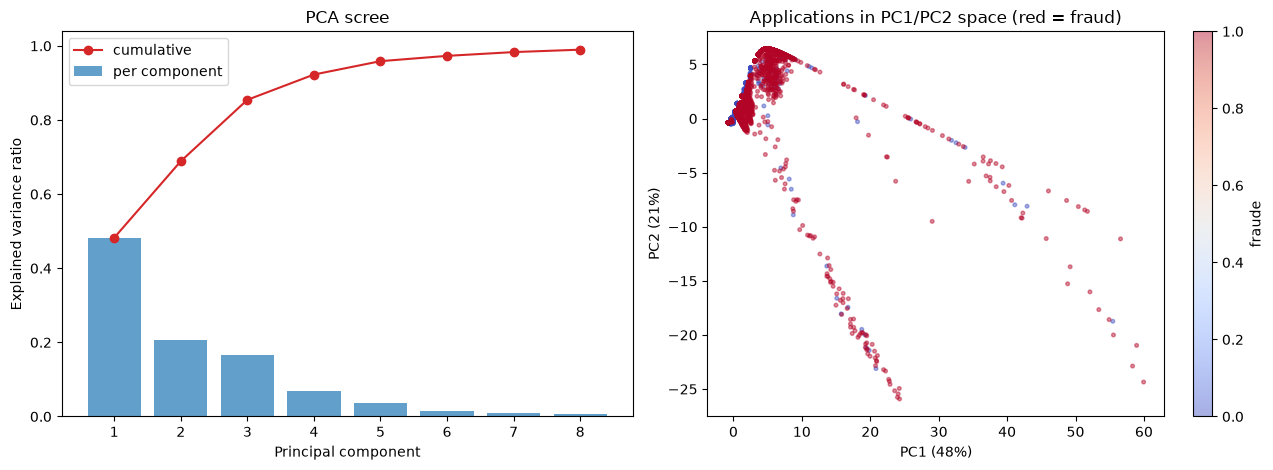

Total variance captured by PC1-PC3: 85%

Top drivers of PC1 (by |loading|):


,PC1,PC2,PC3
nb30j,0.300,-0.077,-0.248
densite_30j,0.300,-0.077,-0.248
nb1an,0.297,-0.236,0.075
nb7j,0.291,-0.027,-0.264
densite_7j,0.291,-0.027,-0.264
b_0_7,0.291,-0.027,-0.264
comm_size,0.273,-0.262,0.155
strong_fanout,0.273,-0.262,0.152
vel_7j,0.216,0.367,0.072
part_recent,0.216,0.367,0.070


In [5]:
# Cell PCA: unsupervised look at the engineered LEAK-SAFE features

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

PCA_FEATURES = [
    "comm_size", "nb7j", "nb30j", "nb1an",
    "densite_7j", "densite_30j", "accel_7_30", "accel_30_1an",
    "b_0_7", "b_7_30", "b_30_210", "b_210_365",
    "age_comm", "recence", "strong_fanout", "n_strong_shared",
    "vel_7j", "part_recent",
]

X = df[PCA_FEATURES].to_numpy(dtype=float)
Xs = StandardScaler().fit_transform(X)

pca = PCA(n_components=min(8, len(PCA_FEATURES)))
Z = pca.fit_transform(Xs)
evr = pca.explained_variance_ratio_

fig, ax = plt.subplots(1, 2, figsize=(13, 4.8))

# --- Scree: how much variance each component captures ---
ax[0].bar(range(1, len(evr) + 1), evr, alpha=0.7, label="per component")
ax[0].plot(range(1, len(evr) + 1), np.cumsum(evr), marker="o", c="tab:red", label="cumulative")
ax[0].set_xlabel("Principal component"); ax[0].set_ylabel("Explained variance ratio")
ax[0].set_title("PCA scree"); ax[0].legend()

# --- 2D map coloured by fraud (subsample for readability) ---
rng = np.random.default_rng(0)
idx = rng.choice(len(df), size=min(20_000, len(df)), replace=False)
order = np.argsort(df["fraude"].to_numpy()[idx])  # draw fraud points on top
idx = idx[order]
sc = ax[1].scatter(Z[idx, 0], Z[idx, 1], c=df["fraude"].to_numpy()[idx],
                   cmap="coolwarm", s=7, alpha=0.45)
ax[1].set_xlabel(f"PC1 ({evr[0]:.0%})"); ax[1].set_ylabel(f"PC2 ({evr[1]:.0%})")
ax[1].set_title("Applications in PC1/PC2 space (red = fraud)")
plt.colorbar(sc, ax=ax[1], label="fraude")
plt.tight_layout(); plt.show()

# --- Loadings: which features drive PC1..PC3 ---
loadings = pd.DataFrame(
    pca.components_[:3].T, index=PCA_FEATURES, columns=["PC1", "PC2", "PC3"],
).round(3)
print(f"Total variance captured by PC1-PC3: {evr[:3].sum():.0%}")
print("\nTop drivers of PC1 (by |loading|):")
display(loadings.reindex(loadings["PC1"].abs().sort_values(ascending=False).index).head(10))

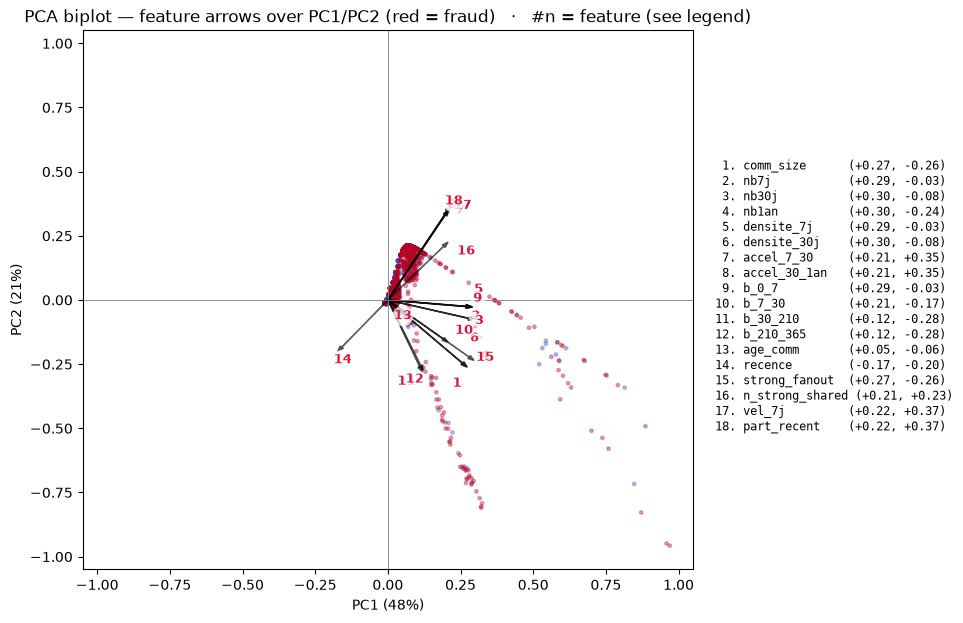

In [11]:
# Cell PCA-biplot: features (arrows) overlaid on the PC1/PC2 cloud
#
# Each arrow is a feature: its direction shows how it contributes to PC1/PC2, its length
# how strongly. Arrows pointing the same way = correlated features. Points = dossiers
# (blue legit / red fraud). Reading it: fraud sits where the "volume + fan-out" arrows point.

comp = pca.components_[:2].T           # loadings for PC1, PC2  -> shape (n_features, 2)

# scale the point cloud to ~unit box so arrows and points share a readable scale
scale = np.abs(Z[:, :2]).max(axis=0)
Zn = Z[:, :2] / scale

rng = np.random.default_rng(0)
idx = rng.choice(len(df), size=min(15_000, len(df)), replace=False)
idx = idx[np.argsort(df["fraude"].to_numpy()[idx])]   # fraud drawn on top

fig, ax = plt.subplots(figsize=(11, 7))
plt.subplots_adjust(right=0.68)   # leave room for the legend on the right
ax.scatter(Zn[idx, 0], Zn[idx, 1], c=df["fraude"].to_numpy()[idx],
           cmap="coolwarm", s=6, alpha=0.35, zorder=1)

# Arrows labelled by NUMBER (names go to a side legend) so collinear features don't overlap.
for k, feat in enumerate(PCA_FEATURES):
    x, y = comp[k, 0], comp[k, 1]
    ax.arrow(0, 0, x, y, color="black", alpha=0.55, head_width=0.015,
             length_includes_head=True, zorder=2)
    norm = max((x**2 + y**2) ** 0.5, 1e-9)
    px, py = -y / norm, x / norm                 # perpendicular unit vector
    lane = ((k % 5) - 2) * 0.035                  # spread near-collinear labels across 5 lanes
    ax.text(x * 1.05 + px * lane, y * 1.05 + py * lane, str(k + 1),
            color="crimson", fontsize=9, fontweight="bold", ha="center", va="center", zorder=3,
            bbox=dict(boxstyle="circle,pad=0.1", fc="white", ec="none", alpha=0.75))

# Numbered legend (feature name + its PC1/PC2 loading) — always readable
legend = "\n".join(
    f"{k + 1:>2}. {feat:<14} ({comp[k, 0]:+.2f}, {comp[k, 1]:+.2f})"
    for k, feat in enumerate(PCA_FEATURES)
)
fig.text(0.70, 0.5, legend, va="center", ha="left", fontsize=8.5, family="monospace")

lim = 1.05
ax.set_xlim(-lim, lim); ax.set_ylim(-lim, lim)
ax.axhline(0, color="grey", lw=0.6); ax.axvline(0, color="grey", lw=0.6)
ax.set_xlabel(f"PC1 ({evr[0]:.0%})"); ax.set_ylabel(f"PC2 ({evr[1]:.0%})")
ax.set_title("PCA biplot — feature arrows over PC1/PC2 (red = fraud)   ·   #n = feature (see legend)")
plt.show()

40 evaluation steps | mean AUC = 0.965 | mean AP = 0.814


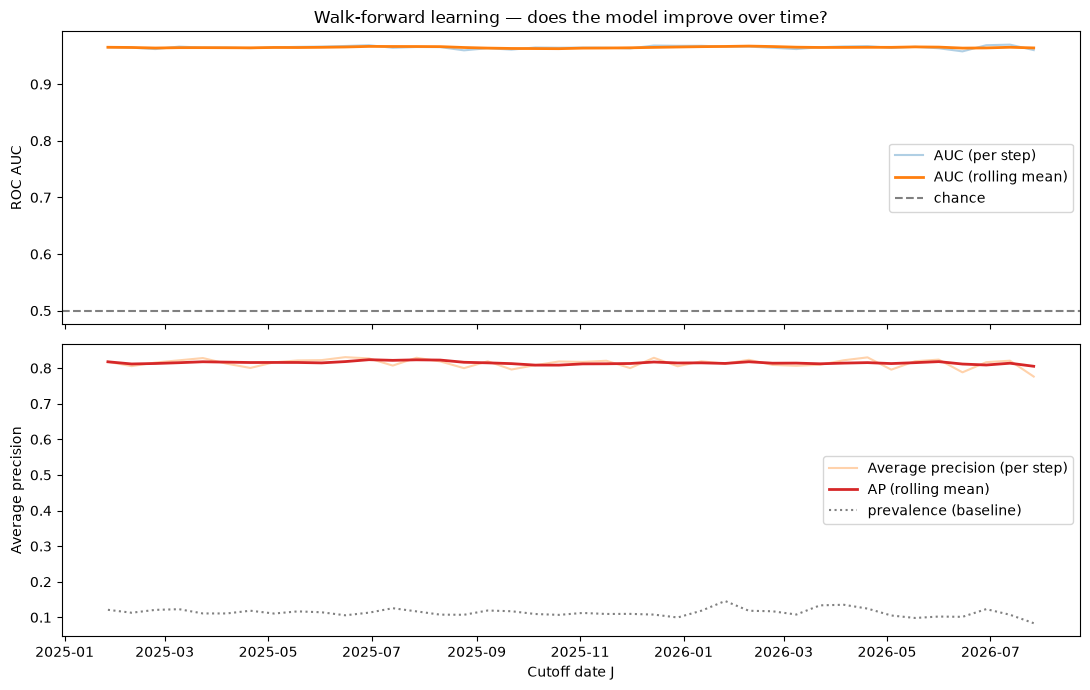

In [6]:
# Cell 7: Walk-forward loop (Steps 1→4) and learning curve
#
# Step 1: advance the cutoff date J by one step (STEP_DAYS).
# Step 2: features already computed point-in-time (Cell 5) -> just filter date < J (past).
# Step 3: predict the applications in the window [J, J+STEP_DAYS).
# Step 4: score the window (AUC, average precision), then iterate until today.

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import roc_auc_score, average_precision_score

# Feature sets:
#   STRUCT    = leak-safe socle (volume + acceleration + strong-id reuse + dynamics), NO label
#   CONFIRMED = STRUCT + label features made leak-safe by a confirmation delay (fraud/defaults)
FEATURES_STRUCT = [
    "comm_size", "nb7j", "nb30j", "nb1an",
    "densite_7j", "densite_30j", "accel_7_30", "accel_30_1an",
    "b_0_7", "b_7_30", "b_30_210", "b_210_365",
    "age_comm", "recence", "strong_fanout", "n_strong_shared",
    "vel_7j", "part_recent",
]
FEATURES_CONFIRMED = FEATURES_STRUCT + ["frd_conf_1an", "frd_conf_2an", "fpd", "spd", "tpd"]
FEATURES = FEATURES_CONFIRMED   # leak-safe socle + confirmation-aware labels
TARGET = "fraude"

WARMUP_DAYS = 180   # minimal history before we start predicting (to fill the 7M/1Y windows)
STEP_DAYS = 14      # loop granularity (7 = weekly, 1 = daily)

start_date, end_date = df["date"].min(), df["date"].max()
cutoff = start_date + pd.Timedelta(days=WARMUP_DAYS)

rows = []
while cutoff < end_date:
    step_end = cutoff + pd.Timedelta(days=STEP_DAYS)
    train = df[df["date"] < cutoff]
    test = df[(df["date"] >= cutoff) & (df["date"] < step_end)]

    if len(test) > 0 and train[TARGET].nunique() == 2 and test[TARGET].nunique() == 2:
        model = make_pipeline(
            StandardScaler(),
            LogisticRegression(class_weight="balanced", max_iter=1000),
        )
        model.fit(train[FEATURES], train[TARGET])
        proba = model.predict_proba(test[FEATURES])[:, 1]
        rows.append({
            "date": cutoff,
            "n_train": len(train),
            "n_test": len(test),
            "auc": roc_auc_score(test[TARGET], proba),
            "ap": average_precision_score(test[TARGET], proba),
            "prevalence": test[TARGET].mean(),
        })
    cutoff = step_end

res = pd.DataFrame(rows)
print(f"{len(res)} evaluation steps | mean AUC = {res['auc'].mean():.3f} | mean AP = {res['ap'].mean():.3f}")

fig, ax = plt.subplots(2, 1, figsize=(11, 7), sharex=True)
ax[0].plot(res["date"], res["auc"], alpha=0.35, label="AUC (per step)")
ax[0].plot(res["date"], res["auc"].rolling(5, min_periods=1).mean(), lw=2, label="AUC (rolling mean)")
ax[0].axhline(0.5, ls="--", c="grey", label="chance")
ax[0].set_ylabel("ROC AUC"); ax[0].legend(); ax[0].set_title("Walk-forward learning — does the model improve over time?")
ax[1].plot(res["date"], res["ap"], alpha=0.35, c="tab:orange", label="Average precision (per step)")
ax[1].plot(res["date"], res["ap"].rolling(5, min_periods=1).mean(), lw=2, c="tab:red", label="AP (rolling mean)")
ax[1].plot(res["date"], res["prevalence"], ls=":", c="grey", label="prevalence (baseline)")
ax[1].set_ylabel("Average precision"); ax[1].set_xlabel("Cutoff date J"); ax[1].legend()
plt.tight_layout(); plt.show()


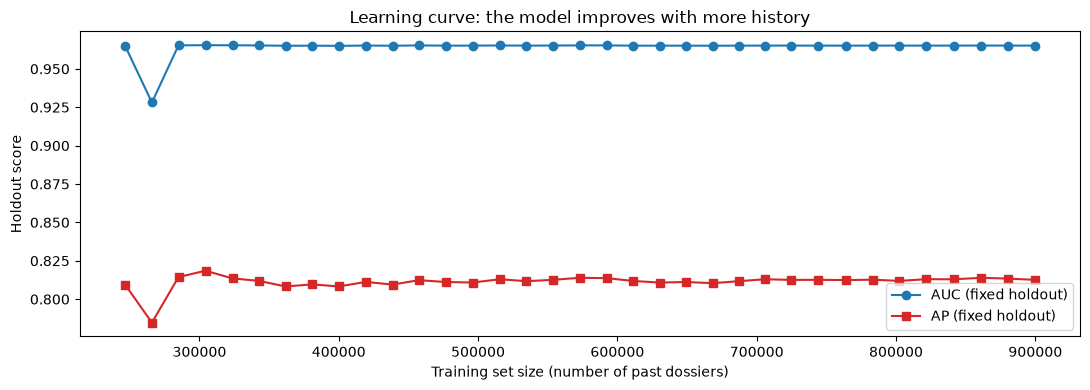

,cutoff,n_train,auc,ap
30,2026-03-22 12:32:08.785840+00:00,821466,0.965150,0.813005
31,2026-04-05 12:32:08.785840+00:00,841518,0.965146,0.812961
32,2026-04-19 12:32:08.785840+00:00,861036,0.965192,0.813900
33,2026-05-03 12:32:08.785840+00:00,880409,0.965174,0.813397
34,2026-05-17 12:32:08.785840+00:00,899423,0.965129,0.812617


In [7]:
# Cell 8: Learning curve — AUC on a FIXED holdout as the history grows
#
# Complement to the walk-forward view: we always evaluate on the last 60 days (frozen holdout),
# gradually increasing the training window. If AUC rises -> the model is learning.

HOLDOUT_DAYS = 60
holdout_start = end_date - pd.Timedelta(days=HOLDOUT_DAYS)
holdout = df[df["date"] >= holdout_start]

curve = []
cutoff = start_date + pd.Timedelta(days=WARMUP_DAYS)
while cutoff < holdout_start:
    train = df[df["date"] < cutoff]
    if train[TARGET].nunique() == 2 and holdout[TARGET].nunique() == 2:
        model = make_pipeline(StandardScaler(), LogisticRegression(class_weight="balanced", max_iter=1000))
        model.fit(train[FEATURES], train[TARGET])
        proba = model.predict_proba(holdout[FEATURES])[:, 1]
        curve.append({"cutoff": cutoff, "n_train": len(train),
                      "auc": roc_auc_score(holdout[TARGET], proba),
                      "ap": average_precision_score(holdout[TARGET], proba)})
    cutoff += pd.Timedelta(days=STEP_DAYS)

curve = pd.DataFrame(curve)
fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(curve["n_train"], curve["auc"], marker="o", label="AUC (fixed holdout)")
ax.plot(curve["n_train"], curve["ap"], marker="s", c="tab:red", label="AP (fixed holdout)")
ax.set_xlabel("Training set size (number of past dossiers)")
ax.set_ylabel("Holdout score")
ax.set_title("Learning curve: the model improves with more history")
ax.legend(); plt.tight_layout(); plt.show()
curve.tail()
